In [1]:
import pandas as pd

In [3]:
df=pd.read_csv("C:\\Users\\deept\\Downloads\\Job_Market_Dataset.csv")
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


In [6]:
df.shape

(40, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Job_ID                     40 non-null     int64 
 1   Job_Title                  40 non-null     object
 2   Job_Category               40 non-null     object
 3   Location                   40 non-null     object
 4   Year                       40 non-null     int64 
 5   Company                    40 non-null     object
 6   Experience_Required_Years  40 non-null     int64 
 7   Salary_Min_LPA             40 non-null     int64 
 8   Salary_Max_LPA             40 non-null     int64 
 9   Employment_Type            40 non-null     object
dtypes: int64(5), object(5)
memory usage: 3.3+ KB


In [9]:
df.dtypes

Job_ID                        int64
Job_Title                    object
Job_Category                 object
Location                     object
Year                          int64
Company                      object
Experience_Required_Years     int64
Salary_Min_LPA                int64
Salary_Max_LPA                int64
Employment_Type              object
dtype: object

In [10]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


Data Cleaning

In [12]:
df.isnull().sum()

Job_ID                       0
Job_Title                    0
Job_Category                 0
Location                     0
Year                         0
Company                      0
Experience_Required_Years    0
Salary_Min_LPA               0
Salary_Max_LPA               0
Employment_Type              0
dtype: int64

no null values

In [14]:
df.duplicated().sum()

np.int64(0)

no duplicate values

In [17]:
numerical_columns = df.select_dtypes(include=["int"])

In [19]:
for i in numerical_columns:
    q1=numerical_columns[i].quantile(0.25)
    q2=numerical_columns[i].quantile(0.50)
    q3=numerical_columns[i].quantile(0.75)

In [20]:
IQR = q3-q1

In [21]:
uw=q3+1.5*IQR
lw=q1-1.5*IQR

In [23]:
Outlier=((numerical_columns[i]>uw)&(numerical_columns[i]<lw))

In [24]:
Outlier.sum()

np.int64(0)

no outliers

In [25]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


In [26]:
df["Salary_Min_LPA"]=df["Salary_Min_LPA"].astype(float)
df["Salary_Max_LPA"]=df["Salary_Max_LPA"].astype(float)

In [27]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4.0,8.0,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8.0,18.0,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6.0,12.0,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15.0,30.0,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5.0,10.0,Full-Time


Salary is converted to float from int

In [30]:
print(df["Experience_Required_Years"].describe())

count    40.000000
mean      2.125000
std       1.066687
min       0.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       4.000000
Name: Experience_Required_Years, dtype: float64


In [31]:
print(df["Year"].describe())

count      40.00000
mean     2024.07500
std         0.79703
min      2023.00000
25%      2023.00000
50%      2024.00000
75%      2025.00000
max      2025.00000
Name: Year, dtype: float64


In [32]:
print(df["Salary_Min_LPA"].describe())

count    40.000000
mean      8.750000
std       5.057363
min       3.000000
25%       4.750000
50%       7.000000
75%      11.250000
max      20.000000
Name: Salary_Min_LPA, dtype: float64


In [33]:
print(df["Salary_Max_LPA"].describe())

count    40.00000
mean     17.32500
std       9.41463
min       6.00000
25%       9.75000
50%      15.00000
75%      21.25000
max      40.00000
Name: Salary_Max_LPA, dtype: float64


In [34]:
print(df["Job_Title"].value_counts())

Job_Title
Data Analyst           7
Business Analyst       5
ML Engineer            5
Data Scientist         5
Data Engineer          3
Power BI Developer     2
AI Engineer            2
SQL Developer          2
SQL Analyst            1
BI Analyst             1
Power BI Consultant    1
Python Data Analyst    1
Power BI Analyst       1
Tableau Developer      1
AI Researcher          1
Python Developer       1
AI Consultant          1
Name: count, dtype: int64


Data Analyst job role has highest demand.

In [36]:
print(df["Company"].value_counts())

Company
Amazon           3
Infosys          2
Reliance         1
ICICI            1
Swiggy           1
PwC              1
Oracle           1
Cognizant        1
HSBC             1
Meta             1
TCS              1
Persistent       1
NVIDIA           1
Zomato           1
L&T              1
McKinsey         1
Freshworks       1
PhonePe          1
Byjus            1
Paytm            1
BCG              1
Tech Mahindra    1
Accenture        1
Google           1
Wipro            1
Deloitte         1
Microsoft        1
HCL              1
JP Morgan        1
Capgemini        1
KPMG             1
EY               1
IBM              1
Flipkart         1
Zoho             1
OpenAI           1
Tesla            1
Name: count, dtype: int64


Amazon is the top company

In [37]:
print(df["Location"].value_counts())

Location
Bangalore    12
Hyderabad     8
Pune          6
Chennai       5
Mumbai        5
Delhi         4
Name: count, dtype: int64


Bangalore has highest companies

In [41]:
df["Salary"]=(df["Salary_Max_LPA"]+df["Salary_Min_LPA"])/2
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type,Salary
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4.0,8.0,Full-Time,6.0
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8.0,18.0,Full-Time,13.0
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6.0,12.0,Full-Time,9.0
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15.0,30.0,Full-Time,22.5
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5.0,10.0,Full-Time,7.5


In [42]:
df.groupby("Salary")["Experience_Required_Years"].mean()*100

Salary
4.5       0.000000
5.0     100.000000
5.5     100.000000
6.0     100.000000
6.5     100.000000
7.5     133.333333
9.0     150.000000
10.0    200.000000
10.5    200.000000
11.0    250.000000
12.0    200.000000
13.0    200.000000
13.5    300.000000
15.0    266.666667
16.0    300.000000
17.0    300.000000
18.5    300.000000
20.0    300.000000
22.0    300.000000
22.5    300.000000
25.0    400.000000
26.5    350.000000
29.0    400.000000
30.0    400.000000
Name: Experience_Required_Years, dtype: float64

In [64]:
df.groupby("Company")["Salary_Min_LPA"].sum()

Company
Accenture         6.0
Amazon           28.0
BCG              10.0
Byjus             4.0
Capgemini         4.0
Cognizant        14.0
Deloitte          4.0
EY                7.0
Flipkart         12.0
Freshworks        8.0
Google           15.0
HCL               3.0
HSBC              6.0
IBM              10.0
ICICI             4.0
Infosys          12.0
JP Morgan         6.0
KPMG              4.0
L&T               4.0
McKinsey         20.0
Meta             18.0
Microsoft        18.0
NVIDIA           16.0
OpenAI           20.0
Oracle           10.0
Paytm             7.0
Persistent        8.0
PhonePe           6.0
PwC               9.0
Reliance          5.0
Swiggy            6.0
TCS               4.0
Tech Mahindra     5.0
Tesla            18.0
Wipro             5.0
Zoho              3.0
Zomato           11.0
Name: Salary_Min_LPA, dtype: float64

In [65]:
df.groupby("Company")["Salary_Max_LPA"].sum()

Company
Accenture        12.0
Amazon           57.0
BCG              20.0
Byjus             7.0
Capgemini         9.0
Cognizant        26.0
Deloitte          9.0
EY               15.0
Flipkart         22.0
Freshworks       16.0
Google           30.0
HCL               7.0
HSBC             12.0
IBM              20.0
ICICI             8.0
Infosys          26.0
JP Morgan        14.0
KPMG              8.0
L&T               9.0
McKinsey         38.0
Meta             35.0
Microsoft        35.0
NVIDIA           28.0
OpenAI           40.0
Oracle           20.0
Paytm            15.0
Persistent       16.0
PhonePe          12.0
PwC              18.0
Reliance         10.0
Swiggy           12.0
TCS               8.0
Tech Mahindra    10.0
Tesla            32.0
Wipro            10.0
Zoho              6.0
Zomato           21.0
Name: Salary_Max_LPA, dtype: float64

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Salary_Min_LPA', ylabel='Job_Title'>

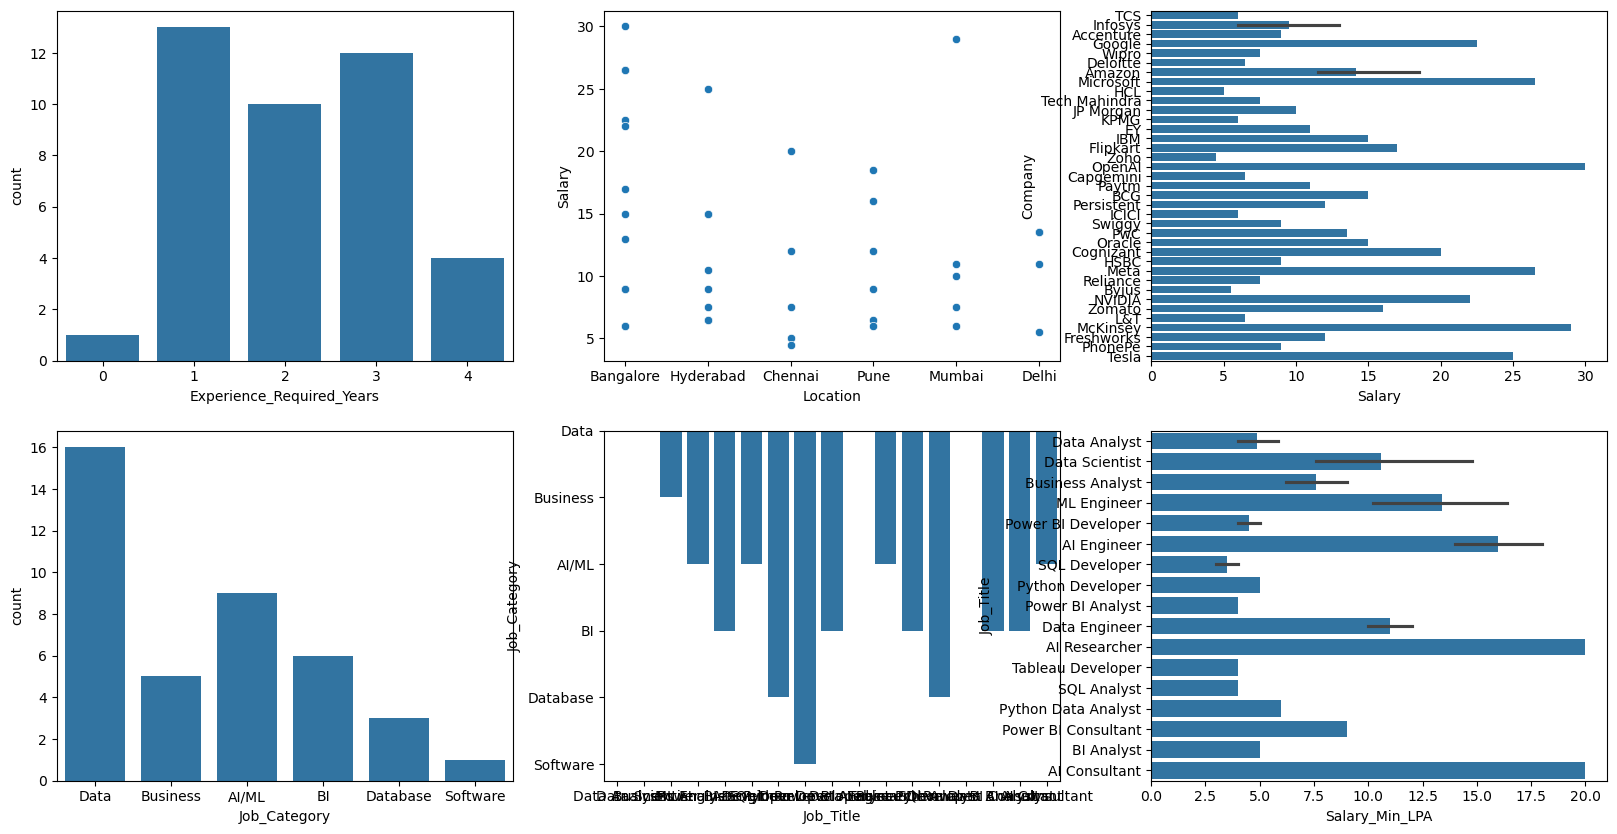

In [62]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x="Experience_Required_Years",data=df)
plt.subplot(2,3,2)
sns.scatterplot(x="Location",y="Salary",data=df)
plt.subplot(2,3,3)
sns.barplot(x='Salary',y='Company',data=df)
plt.subplot(2,3,4)
sns.countplot(x='Job_Category', data=df)
plt.subplot(2,3,5)
sns.barplot(x='Job_Title',y='Job_Category',data=df)
plt.subplot(2,3,6)
sns.barplot(x='Salary_Min_LPA',y='Job_Title',data=df)

In [1]:
import os
os.getcwd()

'C:\\Users\\deept'

In [2]:
import os
os.path.abspath("")

'C:\\Users\\deept'

In [4]:
os.path.join(os.getcwd(), "Job_Market.ipynb")

'C:\\Users\\deept\\Job_Market.ipynb'